准备 backtest input

2. 实现 S1 / S2
3. merge B 的 ml_signals.csv
4. 实现 S3 / S4
5. 计算 performance metrics
6. 输出 strategy_results.csv 和 performance_table.csv

In [2]:
import pandas as pd
import numpy as np
import os

BACKTEST_INPUT_PATH = r"C:/Users/Serena/OneDrive - University of Illinois - Urbana/Desktop/Columbia/5291/Project/Data/output/backtest_input_with_kalman.csv"

backtest_input = pd.read_csv(BACKTEST_INPUT_PATH)
backtest_input["Date"] = pd.to_datetime(backtest_input["Date"])

print(backtest_input.shape)
print(backtest_input.columns.tolist())
backtest_input.head()

(8048, 12)
['Date', 'pair', 'return_y', 'return_x', 'OLS_spread', 'OLS_zscore', 'OLS_beta', 'OLS_alpha', 'Kalman_spread', 'Kalman_zscore', 'Kalman_beta_t', 'Kalman_alpha_t']


,Date,pair,return_y,return_x,OLS_spread,OLS_zscore,OLS_beta,OLS_alpha,Kalman_spread,Kalman_zscore,Kalman_beta_t,Kalman_alpha_t
0,2010-01-04,KO-PEP,NaN,NaN,-0.073419,NaN,0.794323,0.043497,-0.776058,NaN,1.000000,0.000000
1,2010-01-05,KO-PEP,-0.012170,0.012011,-0.095130,NaN,0.794323,0.043497,-0.022343,NaN,0.801323,-0.054767
2,2010-01-06,KO-PEP,-0.000355,-0.010053,-0.087500,NaN,0.794323,0.043497,-0.002736,NaN,0.797392,-0.052407
3,2010-01-07,KO-PEP,-0.002488,-0.006376,-0.084923,NaN,0.794323,0.043497,0.000960,NaN,0.797162,-0.052671
4,2010-01-08,KO-PEP,-0.018682,-0.003286,-0.100995,NaN,0.794323,0.043497,-0.015441,NaN,0.797209,-0.052503


In [3]:
def make_long_backtest_input(backtest_input):
    df = backtest_input.copy()
    df["Date"] = pd.to_datetime(df["Date"])

    # OLS version
    ols = df[[
        "Date",
        "pair",
        "return_y",
        "return_x",
        "OLS_spread",
        "OLS_zscore",
        "OLS_beta",
        "OLS_alpha"
    ]].copy()

    ols = ols.rename(columns={
        "Date": "date",
        "return_y": "ret_y",
        "return_x": "ret_x",
        "OLS_spread": "spread",
        "OLS_zscore": "zscore",
        "OLS_beta": "beta",
        "OLS_alpha": "alpha"
    })

    ols["spread_model"] = "OLS"

    # Kalman version
    kf = df[[
        "Date",
        "pair",
        "return_y",
        "return_x",
        "Kalman_spread",
        "Kalman_zscore",
        "Kalman_beta_t",
        "Kalman_alpha_t"
    ]].copy()

    kf = kf.rename(columns={
        "Date": "date",
        "return_y": "ret_y",
        "return_x": "ret_x",
        "Kalman_spread": "spread",
        "Kalman_zscore": "zscore",
        "Kalman_beta_t": "beta",
        "Kalman_alpha_t": "alpha"
    })

    kf["spread_model"] = "Kalman"

    out = pd.concat([ols, kf], axis=0)
    out = out.sort_values(["pair", "spread_model", "date"])
    out = out.dropna(subset=["zscore", "beta", "ret_y", "ret_x"])

    return out


backtest_long = make_long_backtest_input(backtest_input)

print(backtest_long.shape)
print(backtest_long.groupby(["pair", "spread_model"]).size())
backtest_long.head()

(15088, 9)
pair     spread_model
KO-PEP   Kalman          3772
         OLS             3772
XOM-CVX  Kalman          3772
         OLS             3772
dtype: int64


,date,pair,ret_y,ret_x,spread,zscore,beta,alpha,spread_model
252,2011-01-03,KO-PEP,-0.008398,0.006408,-0.009771,-0.158904,0.812549,-0.003130,Kalman
253,2011-01-04,KO-PEP,-0.020916,-0.005184,-0.023363,-2.560623,0.811521,-0.002418,Kalman
254,2011-01-05,KO-PEP,-0.005968,0.017879,-0.036373,-3.912516,0.809743,-0.003230,Kalman
255,2011-01-06,KO-PEP,-0.007272,0.003747,-0.034982,-3.645722,0.804325,0.005364,Kalman
256,2011-01-07,KO-PEP,-0.001747,-0.006756,-0.020104,-2.072403,0.799371,0.012690,Kalman


In [4]:
def get_strategy_input(df, pair, spread_model):
    out = df[
        (df["pair"] == pair) &
        (df["spread_model"] == spread_model)
    ].copy()

    out = out.sort_values("date").set_index("date")
    return out


df_ols_ko = get_strategy_input(backtest_long, "KO-PEP", "OLS")
df_kf_ko = get_strategy_input(backtest_long, "KO-PEP", "Kalman")

df_ols_xom = get_strategy_input(backtest_long, "XOM-CVX", "OLS")
df_kf_xom = get_strategy_input(backtest_long, "XOM-CVX", "Kalman")

for name, df in {
    "OLS KO-PEP": df_ols_ko,
    "KF KO-PEP": df_kf_ko,
    "OLS XOM-CVX": df_ols_xom,
    "KF XOM-CVX": df_kf_xom,
}.items():
    print(name)
    print(df.shape)
    print(df[["spread", "zscore", "beta", "ret_y", "ret_x"]].isna().sum())
    print()

OLS KO-PEP
(3772, 8)
spread    0
zscore    0
beta      0
ret_y     0
ret_x     0
dtype: int64

KF KO-PEP
(3772, 8)
spread    0
zscore    0
beta      0
ret_y     0
ret_x     0
dtype: int64

OLS XOM-CVX
(3772, 8)
spread    0
zscore    0
beta      0
ret_y     0
ret_x     0
dtype: int64

KF XOM-CVX
(3772, 8)
spread    0
zscore    0
beta      0
ret_y     0
ret_x     0
dtype: int64



In [5]:
ML_SIGNAL_PATH = r"C:/Users/Serena/OneDrive - University of Illinois - Urbana/Desktop/Columbia/5291/Project/Data/output/ml_signals_shallow.csv"

ml_signals = pd.read_csv(ML_SIGNAL_PATH)
ml_signals["date"] = pd.to_datetime(ml_signals["date"])

print(ml_signals.shape)
print(ml_signals.columns.tolist())
ml_signals.head()

(1455, 11)
['date', 'pair', 'spread_model', 'ml_model', 'feature_set', 'n_features', 'z_score', 'label', 'prediction_probability', 'threshold', 'ML_signal']


,date,pair,spread_model,ml_model,feature_set,n_features,z_score,label,prediction_probability,threshold,ML_signal
0,2011-02-10,KO-PEP,Kalman,knn,minimal,5,2.067357,0.0,0.6,0.55,1
1,2011-02-18,KO-PEP,Kalman,knn,minimal,5,2.171639,0.0,0.6,0.55,1
2,2011-03-16,KO-PEP,Kalman,knn,minimal,5,-2.490819,1.0,0.7,0.55,1
3,2011-04-12,KO-PEP,Kalman,knn,minimal,5,-2.051879,0.0,0.6,0.55,1
4,2011-04-26,KO-PEP,Kalman,knn,minimal,5,-2.290733,0.0,0.7,0.55,1


In [6]:
def add_ml_signal(df, ml_signals, pair, spread_model):
    out = df.copy().reset_index()
    out["date"] = pd.to_datetime(out["date"])

    sig = ml_signals[
        (ml_signals["pair"] == pair) &
        (ml_signals["spread_model"] == spread_model)
    ][[
        "date",
        "ML_signal",
        "prediction_probability",
        "threshold",
        "ml_model",
        "feature_set"
    ]].copy()

    sig["date"] = pd.to_datetime(sig["date"])

    out = out.merge(sig, on="date", how="left")

    # Missing ML_signal means ML does not approve trade
    out["ML_signal"] = out["ML_signal"].fillna(0).astype(int)

    return out.sort_values("date").set_index("date")


df_ols_ko_ml = add_ml_signal(df_ols_ko, ml_signals, "KO-PEP", "OLS")
df_kf_ko_ml = add_ml_signal(df_kf_ko, ml_signals, "KO-PEP", "Kalman")

df_ols_xom_ml = add_ml_signal(df_ols_xom, ml_signals, "XOM-CVX", "OLS")
df_kf_xom_ml = add_ml_signal(df_kf_xom, ml_signals, "XOM-CVX", "Kalman")

In [8]:
df_ols_ko_ml.head()

,pair,ret_y,ret_x,spread,zscore,beta,alpha,spread_model,ML_signal,prediction_probability,threshold,ml_model,feature_set
date,,,,,,,,,,,,,
2011-01-03,KO-PEP,-0.008398,0.006408,0.011555,1.936234,0.794323,0.043497,OLS,0,NaN,NaN,NaN,NaN
2011-01-04,KO-PEP,-0.020916,-0.005184,-0.005243,1.675516,0.794323,0.043497,OLS,0,NaN,NaN,NaN,NaN
2011-01-05,KO-PEP,-0.005968,0.017879,-0.025413,1.370863,0.794323,0.043497,OLS,0,NaN,NaN,NaN,NaN
2011-01-06,KO-PEP,-0.007272,0.003747,-0.035661,1.215622,0.794323,0.043497,OLS,0,NaN,NaN,NaN,NaN
2011-01-07,KO-PEP,-0.001747,-0.006756,-0.032041,1.261750,0.794323,0.043497,OLS,0,NaN,NaN,NaN,NaN


In [7]:
for name, df in {
    "OLS KO-PEP ML": df_ols_ko_ml,
    "KF KO-PEP ML": df_kf_ko_ml,
    "OLS XOM-CVX ML": df_ols_xom_ml,
    "KF XOM-CVX ML": df_kf_xom_ml,
}.items():
    print(name)
    print("shape:", df.shape)
    print("ML approval rate:", df["ML_signal"].mean())
    print("ML signal count:", df["ML_signal"].sum())
    print()

OLS KO-PEP ML
shape: (3772, 13)
ML approval rate: 0.06468716861081654
ML signal count: 244

KF KO-PEP ML
shape: (3772, 13)
ML approval rate: 0.03923647932131495
ML signal count: 148

OLS XOM-CVX ML
shape: (3772, 13)
ML approval rate: 0.045068928950159064
ML signal count: 170

KF XOM-CVX ML
shape: (3772, 13)
ML approval rate: 0.018292682926829267
ML signal count: 69



S1 = df_ols_*      + use_ml=False

S2 = df_kf_*       + use_ml=False

S3 = df_ols_*_ml   + use_ml=True

S4 = df_kf_*_ml    + use_ml=True


In [9]:
#backtest_pair_strategy()

def backtest_pair_strategy(
    df,
    pair,
    strategy_name,
    use_ml=False,
    entry_threshold=2.0,
    exit_threshold=0.5,
    max_holding=20,
    cost_bps=5
):
    """
    Backtest one pair strategy.

    Required columns:
        zscore
        beta
        ret_y
        ret_x

    Optional column:
        ML_signal, only used when use_ml=True

    Position meaning:
        +1 = long spread  = long Y, short beta * X
        -1 = short spread = short Y, long beta * X
         0 = flat
    """

    df = df.copy().sort_index()

    cost_rate = cost_bps / 10000

    position = 0
    holding_days = 0

    positions = []
    weight_y_list = []
    weight_x_list = []
    trade_change_list = []
    entry_signal_list = []
    exit_signal_list = []
    holding_days_list = []

    for date, row in df.iterrows():
        z = row["zscore"]
        beta = row["beta"]

        old_position = position
        entry_signal = 0
        exit_signal = 0

        # -----------------------------
        # Exit rule
        # -----------------------------
        if position != 0:
            holding_days += 1

            if abs(z) < exit_threshold:
                position = 0
                holding_days = 0
                exit_signal = 1

            elif holding_days > max_holding:
                position = 0
                holding_days = 0
                exit_signal = 1

        # -----------------------------
        # Entry rule
        # -----------------------------
        if position == 0:
            allow_trade = True

            if use_ml:
                allow_trade = row.get("ML_signal", 0) == 1

            if allow_trade:
                if z < -entry_threshold:
                    position = 1       # long spread
                    holding_days = 1
                    entry_signal = 1

                elif z > entry_threshold:
                    position = -1      # short spread
                    holding_days = 1
                    entry_signal = -1

        # -----------------------------
        # Convert spread position to asset weights
        # -----------------------------
        if position == 0 or pd.isna(beta):
            weight_y = 0.0
            weight_x = 0.0
        else:
            gross = 1 + abs(beta)

            # position = +1: long Y, short beta X
            # position = -1: short Y, long beta X
            weight_y = position / gross
            weight_x = -position * beta / gross

        trade_change = abs(position - old_position)

        positions.append(position)
        weight_y_list.append(weight_y)
        weight_x_list.append(weight_x)
        trade_change_list.append(trade_change)
        entry_signal_list.append(entry_signal)
        exit_signal_list.append(exit_signal)
        holding_days_list.append(holding_days)

    df["pair"] = pair
    df["strategy"] = strategy_name
    df["position"] = positions
    df["weight_y"] = weight_y_list
    df["weight_x"] = weight_x_list
    df["trade_change"] = trade_change_list
    df["entry_signal"] = entry_signal_list
    df["exit_signal"] = exit_signal_list
    df["holding_days"] = holding_days_list

    # Lag weights to avoid look-ahead bias
    df["weight_y_lag"] = df["weight_y"].shift(1).fillna(0)
    df["weight_x_lag"] = df["weight_x"].shift(1).fillna(0)

    # Strategy return
    df["gross_return"] = (
        df["weight_y_lag"] * df["ret_y"] +
        df["weight_x_lag"] * df["ret_x"]
    )

    # Turnover-based transaction cost
    df["turnover"] = (
        df["weight_y"].diff().abs().fillna(df["weight_y"].abs()) +
        df["weight_x"].diff().abs().fillna(df["weight_x"].abs())
    )

    df["transaction_cost"] = cost_rate * df["turnover"]
    df["daily_return"] = df["gross_return"] - df["transaction_cost"]

    df["cumulative_return"] = (1 + df["daily_return"]).cumprod() - 1

    return df

In [10]:
#KO_PEP
results_s1_ko = backtest_pair_strategy(
    df_ols_ko,
    pair="KO-PEP",
    strategy_name="S1_OLS_zscore",
    use_ml=False,
    cost_bps=5
)

results_s2_ko = backtest_pair_strategy(
    df_kf_ko,
    pair="KO-PEP",
    strategy_name="S2_Kalman_zscore",
    use_ml=False,
    cost_bps=5
)

results_s3_ko = backtest_pair_strategy(
    df_ols_ko_ml,
    pair="KO-PEP",
    strategy_name="S3_OLS_ML",
    use_ml=True,
    cost_bps=5
)

results_s4_ko = backtest_pair_strategy(
    df_kf_ko_ml,
    pair="KO-PEP",
    strategy_name="S4_Kalman_ML",
    use_ml=True,
    cost_bps=5
)

In [11]:
#XOM_CVX
results_s1_xom = backtest_pair_strategy(
    df_ols_xom,
    pair="XOM-CVX",
    strategy_name="S1_OLS_zscore",
    use_ml=False,
    cost_bps=5
)

results_s2_xom = backtest_pair_strategy(
    df_kf_xom,
    pair="XOM-CVX",
    strategy_name="S2_Kalman_zscore",
    use_ml=False,
    cost_bps=5
)

results_s3_xom = backtest_pair_strategy(
    df_ols_xom_ml,
    pair="XOM-CVX",
    strategy_name="S3_OLS_ML",
    use_ml=True,
    cost_bps=5
)

results_s4_xom = backtest_pair_strategy(
    df_kf_xom_ml,
    pair="XOM-CVX",
    strategy_name="S4_Kalman_ML",
    use_ml=True,
    cost_bps=5
)

In [12]:
#Performance metrics
def compute_performance_metrics(df):
    daily_ret = df["daily_return"].dropna()

    if len(daily_ret) == 0:
        return {}

    total_return = (1 + daily_ret).prod() - 1

    annualized_return = (1 + total_return) ** (252 / len(daily_ret)) - 1
    annualized_vol = daily_ret.std() * np.sqrt(252)

    sharpe = annualized_return / annualized_vol if annualized_vol != 0 else np.nan

    cumulative = (1 + daily_ret).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    max_drawdown = drawdown.min()

    trades = (df["entry_signal"] != 0).sum()
    exits = (df["exit_signal"] != 0).sum()
    turnover = df["turnover"].sum()

    win_rate_daily = (daily_ret > 0).mean()

    active_days = (df["position"].abs() > 0).sum()
    active_ratio = active_days / len(df)

    avg_daily_return = daily_ret.mean()

    return {
        "pair": df["pair"].iloc[0],
        "strategy": df["strategy"].iloc[0],
        "total_return": total_return,
        "annualized_return": annualized_return,
        "annualized_vol": annualized_vol,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
        "win_rate_daily": win_rate_daily,
        "avg_daily_return": avg_daily_return,
        "turnover": turnover,
        "trades": trades,
        "exits": exits,
        "active_days": active_days,
        "active_ratio": active_ratio
    }

In [13]:
all_strategy_results = pd.concat(
    [
        results_s1_ko,
        results_s2_ko,
        results_s3_ko,
        results_s4_ko,
        results_s1_xom,
        results_s2_xom,
        results_s3_xom,
        results_s4_xom,
    ],
    axis=0
)

performance_table = pd.DataFrame([
    compute_performance_metrics(results_s1_ko),
    compute_performance_metrics(results_s2_ko),
    compute_performance_metrics(results_s3_ko),
    compute_performance_metrics(results_s4_ko),
    compute_performance_metrics(results_s1_xom),
    compute_performance_metrics(results_s2_xom),
    compute_performance_metrics(results_s3_xom),
    compute_performance_metrics(results_s4_xom),
])

performance_table

,pair,strategy,total_return,annualized_return,annualized_vol,sharpe,max_drawdown,win_rate_daily,avg_daily_return,turnover,trades,exits,active_days,active_ratio
0,KO-PEP,S1_OLS_zscore,0.059964,0.003898,0.040009,0.097431,-0.137692,0.127784,0.000019,64.000000,49,49,970,0.257158
1,KO-PEP,S2_Kalman_zscore,0.063987,0.004152,0.036001,0.115339,-0.127374,0.069724,0.000019,220.383337,110,110,531,0.140774
2,KO-PEP,S3_OLS_ML,0.025911,0.001710,0.034178,0.050047,-0.134010,0.096766,0.000009,68.000000,36,36,714,0.189290
3,KO-PEP,S4_Kalman_ML,-0.080388,-0.005583,0.031770,-0.175738,-0.160373,0.054348,-0.000020,164.291835,82,82,419,0.111082
4,XOM-CVX,S1_OLS_zscore,0.084915,0.005460,0.048133,0.113432,-0.135066,0.142895,0.000026,69.000000,53,52,1043,0.276511
5,XOM-CVX,S2_Kalman_zscore,-0.027675,-0.001873,0.039890,-0.046961,-0.136923,0.065217,-0.000004,218.409524,109,109,481,0.127519
6,XOM-CVX,S3_OLS_ML,0.285347,0.016912,0.043488,0.388890,-0.064680,0.113468,0.000070,68.000000,41,41,817,0.216596
7,XOM-CVX,S4_Kalman_ML,0.079475,0.005122,0.027027,0.189523,-0.068490,0.032344,0.000022,110.198768,55,55,218,0.057794


In [15]:

OUTPUT_DIR = "C:/Users/Serena/OneDrive - University of Illinois - Urbana/Desktop/Columbia/5291/Project/Data/output"

strategy_results_path = OUTPUT_DIR + "/strategy_results.csv"
performance_table_path = OUTPUT_DIR + "/performance_table.csv"

all_strategy_results.reset_index().to_csv(strategy_results_path, index=False)
performance_table.to_csv(performance_table_path, index=False)

print("Saved strategy results to:", strategy_results_path)
print("Saved performance table to:", performance_table_path)

Saved strategy results to: C:/Users/Serena/OneDrive - University of Illinois - Urbana/Desktop/Columbia/5291/Project/Data/output/strategy_results.csv
Saved performance table to: C:/Users/Serena/OneDrive - University of Illinois - Urbana/Desktop/Columbia/5291/Project/Data/output/performance_table.csv


sanity check

In [16]:
performance_table.sort_values(["pair", "strategy"])

,pair,strategy,total_return,annualized_return,annualized_vol,sharpe,max_drawdown,win_rate_daily,avg_daily_return,turnover,trades,exits,active_days,active_ratio
0,KO-PEP,S1_OLS_zscore,0.059964,0.003898,0.040009,0.097431,-0.137692,0.127784,0.000019,64.000000,49,49,970,0.257158
1,KO-PEP,S2_Kalman_zscore,0.063987,0.004152,0.036001,0.115339,-0.127374,0.069724,0.000019,220.383337,110,110,531,0.140774
2,KO-PEP,S3_OLS_ML,0.025911,0.001710,0.034178,0.050047,-0.134010,0.096766,0.000009,68.000000,36,36,714,0.189290
3,KO-PEP,S4_Kalman_ML,-0.080388,-0.005583,0.031770,-0.175738,-0.160373,0.054348,-0.000020,164.291835,82,82,419,0.111082
4,XOM-CVX,S1_OLS_zscore,0.084915,0.005460,0.048133,0.113432,-0.135066,0.142895,0.000026,69.000000,53,52,1043,0.276511
5,XOM-CVX,S2_Kalman_zscore,-0.027675,-0.001873,0.039890,-0.046961,-0.136923,0.065217,-0.000004,218.409524,109,109,481,0.127519
6,XOM-CVX,S3_OLS_ML,0.285347,0.016912,0.043488,0.388890,-0.064680,0.113468,0.000070,68.000000,41,41,817,0.216596
7,XOM-CVX,S4_Kalman_ML,0.079475,0.005122,0.027027,0.189523,-0.068490,0.032344,0.000022,110.198768,55,55,218,0.057794


In [17]:
all_strategy_results.groupby(["pair", "strategy"])[
    ["daily_return", "turnover", "position"]
].describe()

daily_return                                          \
                                count      mean       std       min  25%  50%   
pair    strategy                                                                
KO-PEP  S1_OLS_zscore          3772.0  0.000019  0.002520 -0.025546  0.0  0.0   
        S2_Kalman_zscore       3772.0  0.000019  0.002268 -0.035632  0.0  0.0   
        S3_OLS_ML              3772.0  0.000009  0.002153 -0.025546  0.0  0.0   
        S4_Kalman_ML           3772.0 -0.000020  0.002001 -0.028011  0.0  0.0   
XOM-CVX S1_OLS_zscore          3772.0  0.000026  0.003032 -0.043044 -0.0  0.0   
        S2_Kalman_zscore       3772.0 -0.000004  0.002513 -0.043911  0.0  0.0   
        S3_OLS_ML              3772.0  0.000070  0.002740 -0.043044  0.0  0.0   
        S4_Kalman_ML           3772.0  0.000022  0.001703 -0.043911  0.0  0.0   

                                        turnover            ...            \
                          75%       max    count      mean  ...  75%  max   
pair    strategy                                            ...             
KO-PEP  S1_OLS_zscore     0.0  0.034950   3772.0  0.016967  ...  0.0  1.0   
        S2_Kalman_zscore  0.0  0.028010   3772.0  0.058426  ...  0.0  1.0   
        S3_OLS_ML         0.0  0.034950   3772.0  0.018028  ...  0.0  1.0   
        S4_Kalman_ML      0.0  0.035629   3772.0  0.043556  ...  0.0  1.0   
XOM-CVX S1_OLS_zscore     0.0  0.055605   3772.0  0.018293  ...  0.0  1.0   
        S2_Kalman_zscore  0.0  0.039902   3772.0  0.057903  ...  0.0  1.0   
        S3_OLS_ML         0.0  0.055605   3772.0  0.018028  ...  0.0  1.0   
        S4_Kalman_ML      0.0  0.039902   3772.0  0.029215  ...  0.0  1.0   

                         position                                               
                            count      mean       std  min  25%  50%  75%  max  
pair    strategy                                                                
KO-PEP  S1_OLS_zscore      3772.0 -0.058855  0.503747 -1.0  0.0  0.0  0.0  1.0  
        S2_Kalman_zscore   3772.0 -0.017762  0.374828 -1.0  0.0  0.0  0.0  1.0  
        S3_OLS_ML          3772.0 -0.033404  0.433847 -1.0  0.0  0.0  0.0  1.0  
        S4_Kalman_ML       3772.0 -0.009809  0.333189 -1.0  0.0  0.0  0.0  1.0  
XOM-CVX S1_OLS_zscore      3772.0 -0.022004  0.525452 -1.0  0.0  0.0  0.0  1.0  
        S2_Kalman_zscore   3772.0 -0.014581  0.356847 -1.0  0.0  0.0  0.0  1.0  
        S3_OLS_ML          3772.0 -0.004507  0.465439 -1.0  0.0  0.0  0.0  1.0  
        S4_Kalman_ML       3772.0 -0.004772  0.240389 -1.0  0.0  0.0  0.0  1.0  

[8 rows x 24 columns]

In [18]:
for name, df in {
    "S1 KO": results_s1_ko,
    "S2 KO": results_s2_ko,
    "S3 KO": results_s3_ko,
    "S4 KO": results_s4_ko,
    "S1 XOM": results_s1_xom,
    "S2 XOM": results_s2_xom,
    "S3 XOM": results_s3_xom,
    "S4 XOM": results_s4_xom,
}.items():
    print(name)
    print("trades:", (df["entry_signal"] != 0).sum())
    print("active ratio:", (df["position"].abs() > 0).mean())
    print("final cumulative return:", df["cumulative_return"].iloc[-1])
    print()

S1 KO
trades: 49
active ratio: 0.25715800636267233
final cumulative return: 0.05996375581706648

S2 KO
trades: 110
active ratio: 0.14077412513255566
final cumulative return: 0.06398736102564118

S3 KO
trades: 36
active ratio: 0.18928950159066807
final cumulative return: 0.025911285402979933

S4 KO
trades: 82
active ratio: 0.11108165429480382
final cumulative return: -0.08038842468088825

S1 XOM
trades: 53
active ratio: 0.27651113467656413
final cumulative return: 0.0849146767789255

S2 XOM
trades: 109
active ratio: 0.1275185577942736
final cumulative return: -0.027675420282728735

S3 XOM
trades: 41
active ratio: 0.21659597030752917
final cumulative return: 0.2853474616671754

S4 XOM
trades: 55
active ratio: 0.057794273594909865
final cumulative return: 0.07947478265887642



In [ ]:
#plot
import os
import matplotlib.pyplot as plt

PLOT_DIR = OUTPUT_DIR + "/backtest_plots"

def safe_name(name):
    return (
        name.lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
        .replace(":", "")
    )

def plot_cumulative_returns(results_list, title, save=True):
    fig, ax = plt.subplots(figsize=(10, 5))

    for df in results_list:
        label = df["strategy"].iloc[0]
        ax.plot(df.index, df["cumulative_return"], label=label)

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative Return")
    ax.legend()
    ax.grid(True, alpha=0.3)

    if save:
        filename = safe_name(title) + ".png"
        save_path = os.path.join(PLOT_DIR, filename)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()

Saved: C:/Users/Serena/OneDrive - University of Illinois - Urbana/Desktop/Columbia/5291/Project/Data/output/backtest_plots\ko_pep_strategy_cumulative_returns.png


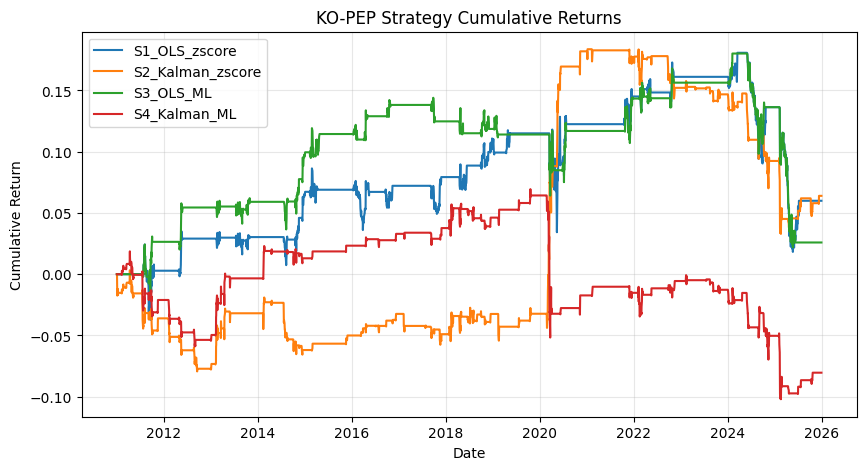

Saved: C:/Users/Serena/OneDrive - University of Illinois - Urbana/Desktop/Columbia/5291/Project/Data/output/backtest_plots\xom_cvx_strategy_cumulative_returns.png


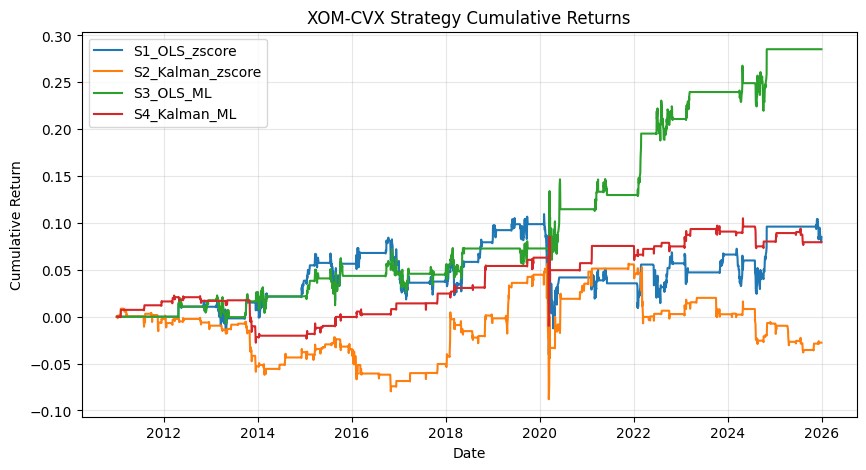

In [23]:
plot_cumulative_returns(
    [results_s1_ko, results_s2_ko, results_s3_ko, results_s4_ko],
    "KO-PEP Strategy Cumulative Returns"
)

plot_cumulative_returns(
    [results_s1_xom, results_s2_xom, results_s3_xom, results_s4_xom],
    "XOM-CVX Strategy Cumulative Returns"
)